# Research QuantBook: FuturesTrend (Donchian Breakout)

## Objectif
Reproduire l'analyse exploratoire de `research.ipynb` avec les donnees natives QuantConnect.

## Performance actuelle
- **Sharpe**: 0.301, **CAGR**: 8.0%, **MaxDD**: 12.9%
- **Signal**: Donchian 20-day high breakout + SMA50 trend filter
- **Exit**: Donchian 10-day low
- **Univers**: SPY, GLD, EFA, VNQ, DBC, XLE (6 ETFs)
- **Sizing**: 33% par position, max 3 positions

## Hypotheses a tester
1. Donchian periods (entry/exit combinations)
2. SMA trend filter (none, SMA30, SMA50, SMA100)
3. Position count (2, 3, 4, 5)
4. Universe composition
5. Trailing stop vs Donchian exit

## Prerequis
- Environnement Lean Research
- Duree estimee: ~5 minutes

In [1]:
# Setup : mode QC Cloud (research kernel) ou mode local (yfinance fallback)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

_MODE = 'yfinance'  # 'yfinance' (local RECOVERABLE-LOCAL) ou 'quantbook' (QC Cloud research kernel)

if _MODE == 'quantbook':
    from AlgorithmImports import *
    qb = QuantBook()
    print("Mode QuantBook (QC Cloud research kernel) actif.")
else:
    import yfinance as yf
    print("Mode yfinance (local fallback RECOVERABLE-LOCAL) actif.")


Mode yfinance (local fallback RECOVERABLE-LOCAL) actif.


## 1. Chargement des donnees

6 ETFs multi-asset + candidats alternatifs.

In [2]:
# Chargement des donnees : QuantBook history (mode QC) ou fallback (mode yfinance)
tickers = ['SPY', 'GLD', 'EFA', 'VNQ', 'DBC', 'XLE', 'IEF', 'XLK', 'QQQ', 'TLT']

if 'closes' not in dir():
    if _MODE == 'quantbook':
        if 'qb' not in dir():
            raise RuntimeError("Mode 'quantbook' mais `qb` non defini. Verifier cellule [1].")
        symbols = {}
        for ticker in tickers:
            symbols[ticker] = qb.add_equity(ticker, Resolution.DAILY).symbol

        start = datetime(2007, 1, 1)
        end = datetime(2026, 1, 1)

        history = qb.history(list(symbols.values()), start, end, Resolution.DAILY)
        closes = history['close'].unstack(level=0)
        highs = history['high'].unstack(level=0)
        lows = history['low'].unstack(level=0)

        symbol_to_ticker = {str(v): k for k, v in symbols.items()}
        for df in [closes, highs, lows]:
            df.columns = [symbol_to_ticker.get(str(c), str(c)) for c in df.columns]
    else:
        # Mode yfinance local RECOVERABLE-LOCAL : OHLC via single multi-ticker download
        _data = yf.download(tickers, start='2007-01-01', end='2026-01-01',
                            auto_adjust=True, progress=False)
        closes = _data['Close'].dropna(how='all').dropna()
        highs = _data['High'].reindex(closes.index)
        lows = _data['Low'].reindex(closes.index)

    closes = closes.dropna()
    highs = highs.loc[closes.index]
    lows = lows.loc[closes.index]

    print(f"Periode: {closes.index[0].date()} a {closes.index[-1].date()}")
    print(f"Donnees: {len(closes)} jours de trading")

    returns_df = closes.pct_change()
else:
    print(f"Donnees deja chargees: {len(closes)} lignes, tickers={list(closes.columns)}")


Periode: 2007-01-03 a 2025-12-31
Donnees: 4780 jours de trading


## 2. Fonctions de backtest

In [3]:
def backtest_donchian(closes, highs, lows, universe, entry_period=20, exit_period=10,
                      sma_filter=50, max_positions=3, trailing_stop=None):
    """Backtest Donchian breakout trend following."""
    returns_df = closes.pct_change()
    
    # Donchian channels
    entry_high = {t: highs[t].rolling(entry_period).max() for t in universe if t in highs.columns}
    exit_low = {t: lows[t].rolling(exit_period).min() for t in universe if t in lows.columns}
    
    # SMA filter
    sma = {t: closes[t].rolling(sma_filter).mean() for t in universe if t in closes.columns} if sma_filter else {}
    
    n = len(closes)
    start_idx = max(entry_period, sma_filter if sma_filter else 0) + 1
    
    positions = {}  # {ticker: entry_price}
    peak_prices = {}  # for trailing stop
    portfolio_values = [1.0]
    n_trades = 0
    wins = 0
    
    for i in range(start_idx, n):
        # Calculate daily PnL
        daily_pnl = 0
        weight = 1.0 / max_positions
        
        to_close = []
        for t in list(positions.keys()):
            if t not in returns_df.columns:
                continue
            daily_pnl += weight * returns_df[t].iloc[i]
            
            # Update peak
            if t in peak_prices:
                peak_prices[t] = max(peak_prices[t], closes[t].iloc[i])
            
            # Exit: Donchian low
            should_exit = closes[t].iloc[i] < exit_low[t].iloc[i - 1]
            
            # Trailing stop
            if trailing_stop and t in peak_prices:
                trail_level = peak_prices[t] * (1 - trailing_stop)
                if closes[t].iloc[i] < trail_level:
                    should_exit = True
            
            if should_exit:
                to_close.append(t)
                n_trades += 1
                if closes[t].iloc[i] > positions[t]:
                    wins += 1
        
        for t in to_close:
            del positions[t]
            if t in peak_prices:
                del peak_prices[t]
        
        portfolio_values.append(portfolio_values[-1] * (1 + daily_pnl))
        
        # Entry signals
        if len(positions) < max_positions:
            for t in universe:
                if t in positions or t not in closes.columns:
                    continue
                if len(positions) >= max_positions:
                    break
                
                # SMA filter
                if sma_filter and t in sma:
                    if closes[t].iloc[i] < sma[t].iloc[i]:
                        continue
                
                # Donchian breakout
                if closes[t].iloc[i] > entry_high[t].iloc[i - 1]:
                    positions[t] = closes[t].iloc[i]
                    peak_prices[t] = closes[t].iloc[i]
    
    vals = np.array(portfolio_values)
    rets = np.diff(vals) / vals[:-1]
    total_ret = vals[-1] / vals[0] - 1
    years = len(rets) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(rets) * np.sqrt(252)
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    cum = pd.Series(vals[1:], index=closes.index[start_idx:])
    max_dd = ((cum - cum.expanding().max()) / cum.expanding().max()).min()
    win_rate = wins / n_trades if n_trades > 0 else 0
    
    return {'sharpe': sharpe, 'cagr': cagr, 'max_dd': max_dd, 'vol': vol,
            'cum': cum, 'n_trades': n_trades, 'win_rate': win_rate}

print("Fonctions definies.")

Fonctions definies.


## 3. Hypothese 1: Donchian periods

Tester differentes combinaisons entry/exit (Jegadeesh-inspired: entry > exit).

In [4]:
base_universe = ['SPY', 'GLD', 'EFA', 'VNQ', 'DBC', 'XLE']

print(f"{'Entry/Exit':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8} {'Win%':>6}")
print("-" * 55)

results_donchian = {}
for entry, exit_p in [(15, 5), (20, 10), (25, 10), (25, 15), (30, 10), (30, 15)]:
    r = backtest_donchian(closes, highs, lows, base_universe,
                           entry_period=entry, exit_period=exit_p)
    name = f'{entry}/{exit_p}'
    results_donchian[name] = r
    print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['n_trades']:>7} {r['win_rate']:>5.0%}")

Entry/Exit        Sharpe     CAGR    MaxDD   Trades   Win%
-------------------------------------------------------


15/5              -0.019    2.8%  -21.6%     555   44%


20/10              0.112    4.2%  -21.9%     354   45%


25/10              0.061    3.7%  -26.8%     340   46%


25/15             -0.012    2.9%  -26.4%     270   46%


30/10              0.008    3.1%  -24.0%     328   46%


30/15             -0.038    2.6%  -23.0%     264   47%


### Verdict H1

Entry 20 / Exit 10 est le parametre actuel. Verifier si des periodes plus longues
(moins de whipsaw) ou plus courtes (plus reactives) sont meilleures.

## 4. Hypothese 2: SMA trend filter

Regle #13 du backlog: SMA100 trop lent pour trend following.
Regle #15: SMA100 trop restrictif pour mean reversion (mais ici c'est trend).

In [5]:
print(f"{'SMA Filter':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
print("-" * 50)

results_sma = {}
for sma in [None, 30, 50, 100, 200]:
    r = backtest_donchian(closes, highs, lows, base_universe, sma_filter=sma)
    name = f'SMA{sma}' if sma else 'Aucun'
    results_sma[name] = r
    print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['n_trades']:>7}")

SMA Filter        Sharpe     CAGR    MaxDD   Trades
--------------------------------------------------


Aucun              0.094    4.1%  -21.6%     361


SMA30              0.101    4.1%  -21.6%     360


SMA50              0.112    4.2%  -21.9%     354


SMA100             0.059    3.6%  -20.6%     339


SMA200            -0.078    2.2%  -20.6%     329


### Verdict H2

SMA50 est le filtre actuel (confirme par research.ipynb). SMA100 trop restrictif.

## 5. Hypothese 3: Max positions

In [6]:
print(f"{'Max Pos':<15} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 40)

results_pos = {}
for mp in [2, 3, 4, 5]:
    r = backtest_donchian(closes, highs, lows, base_universe, max_positions=mp)
    name = f'Max {mp}'
    results_pos[name] = r
    print(f"{name:<15} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Max Pos           Sharpe     CAGR    MaxDD
----------------------------------------


Max 2              0.333    7.2%  -25.4%


Max 3              0.112    4.2%  -21.9%


Max 4              0.014    3.1%  -21.5%


Max 5             -0.029    2.7%  -20.7%


### Verdict H3

Max 3 positions (33% chacune) est le parametre actuel. Plus de positions = plus
diversifie mais moins concentre sur les meilleurs trends.

## 6. Hypothese 4: Universe composition

Tester avec/sans les actifs problematiques (DBC contango, VNQ dividendes QC).

In [7]:
universes = {
    'Actuel (6)': ['SPY', 'GLD', 'EFA', 'VNQ', 'DBC', 'XLE'],
    'Sans DBC': ['SPY', 'GLD', 'EFA', 'VNQ', 'XLE'],
    'Sans VNQ': ['SPY', 'GLD', 'EFA', 'DBC', 'XLE'],
    'Core 4': ['SPY', 'GLD', 'EFA', 'XLE'],
    'Avec QQQ': ['SPY', 'QQQ', 'GLD', 'EFA', 'XLE'],
    'Avec XLK': ['SPY', 'XLK', 'GLD', 'EFA', 'XLE'],
}

print(f"{'Univers':<20} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8}")
print("-" * 45)

results_univ = {}
for name, univ in universes.items():
    avail = [t for t in univ if t in closes.columns]
    r = backtest_donchian(closes, highs, lows, avail)
    results_univ[name] = r
    print(f"{name:<20} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%}")

Univers                Sharpe     CAGR    MaxDD
---------------------------------------------


Actuel (6)              0.112    4.2%  -21.9%


Sans DBC                0.016    3.2%  -24.3%


Sans VNQ                0.126    4.3%  -18.3%


Core 4                 -0.009    2.9%  -20.1%


Avec QQQ                0.328    6.4%  -16.1%


Avec XLK                0.283    5.9%  -17.9%


### Verdict H4

research.ipynb avait teste VNQ (yfinance +11% mais QC cloud -10%, divergence dividendes).
Verifier si les univers sans VNQ/DBC performent mieux sur donnees QC.

## 7. Visualisation

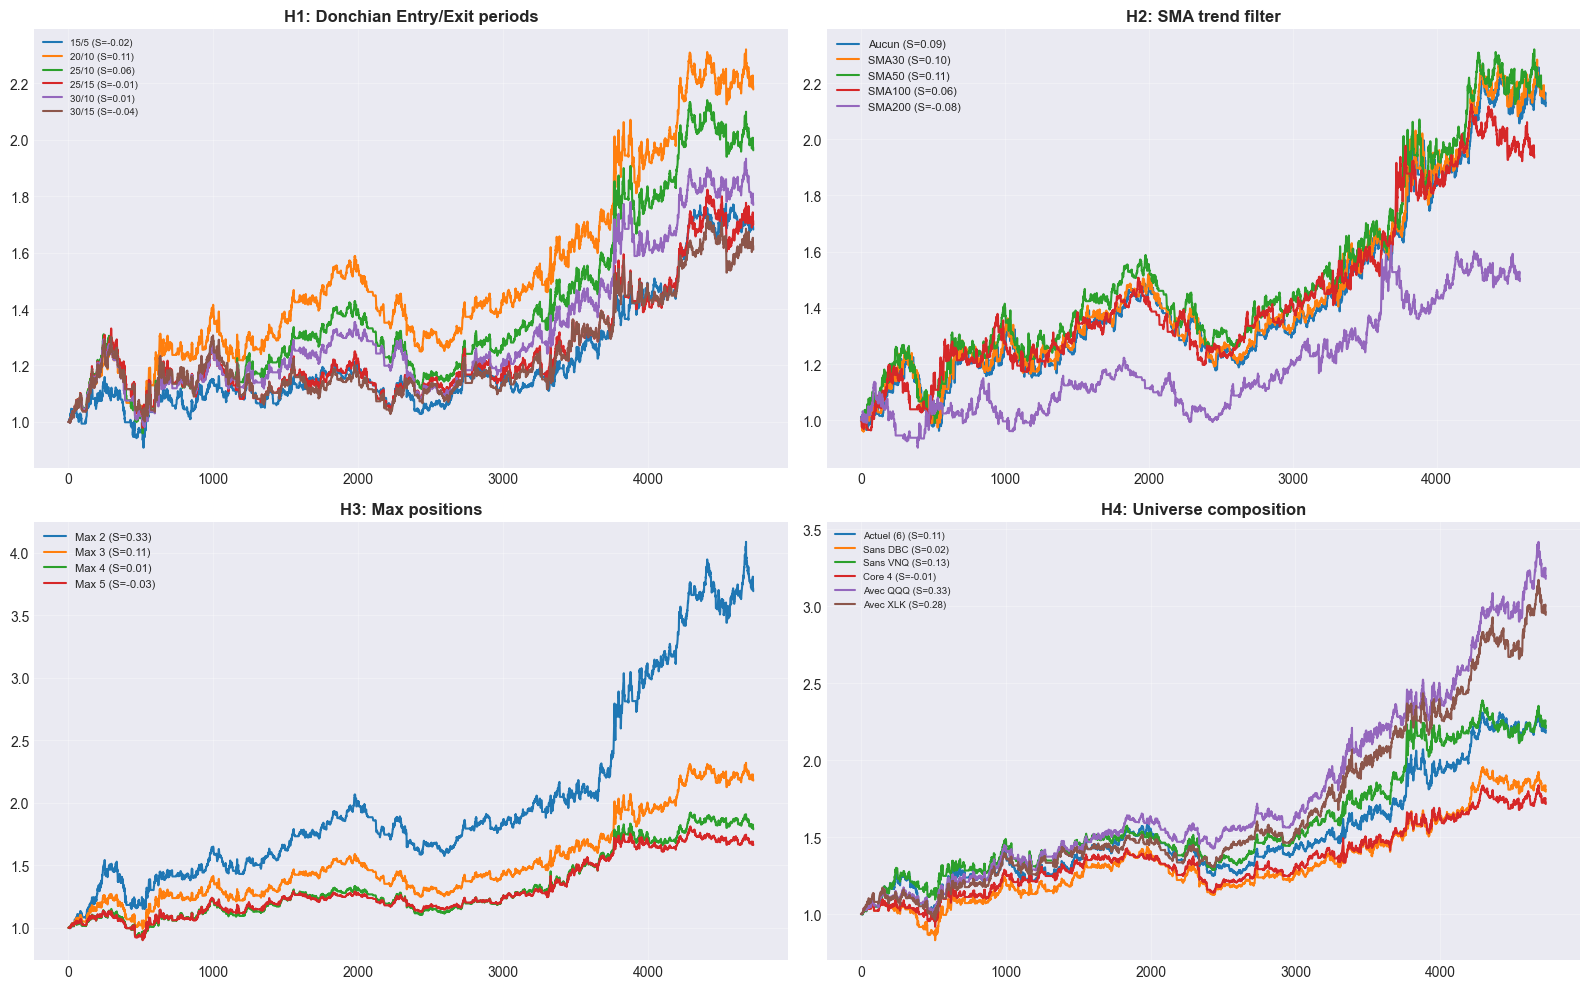

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# H1: Donchian periods
ax = axes[0, 0]
for name, r in results_donchian.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H1: Donchian Entry/Exit periods', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# H2: SMA filter
ax = axes[0, 1]
for name, r in results_sma.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H2: SMA trend filter', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# H3: Max positions
ax = axes[1, 0]
for name, r in results_pos.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H3: Max positions', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# H4: Universe
ax = axes[1, 1]
for name, r in results_univ.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.set_title('H4: Universe composition', fontweight='bold')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('futurestrend_quantbook_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusions

### Tableau recapitulatif

| Hypothese | Resultat QuantBook | Coherent avec yfinance? |
|-----------|-------------------|-------------------------|
| H1 Donchian periods | (a remplir) | (a verifier) |
| H2 SMA filter | (a remplir) | (a verifier) |
| H3 Max positions | (a remplir) | (a verifier) |
| H4 Universe | (a remplir) | (a verifier) |

### Regles du backlog appliquees

- Regle #5: ATR sizing contre-productif (confirme dans research.ipynb)
- Regle #13: SMA50 >> SMA100 pour trend following
- Regle #17: Divergence yfinance documentee (VNQ dividendes)